# Project 18 — Cherry-Blossom Timing (B-splines, + optional HSGP)

**Tier 4 · Advanced** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P18_cherry-splines/P18_cherry-splines_12-06-2026_Opus48.ipynb)

Model the **smooth, wiggly trend** in the date of first cherry blossom in Kyoto across ~1200 years
using **B-splines** — a basis expansion that captures non-linear time trends at **O(n)** cost. We
deliberately avoid an exact Gaussian process (O(n³) on ~800 points blows the runtime budget, §7.7)
and offer **HSGP** (Hilbert-space approximate GP) as the scalable optional path.

## Learning objectives
1. Build a **B-spline basis** over `year` and fit `doy = a + B·w` with PyMC.
2. Understand why a basis expansion beats an exact GP at this n (runtime, §7.7).
3. Run **SBC** (Tier 4 requirement) on the noise/intercept of a reduced spline.
4. Compare the spline against a straight-line trend with PSIS-LOO, and (optionally) reproduce the
   smooth with a **`pm.gp.HSGP`**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
from scipy.interpolate import BSpline
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 18
rng = np.random.default_rng(RANDOM_SEED)
trapz = getattr(np, "trapezoid", None) or np.trapz
print("pymc", pm.__version__, "| arviz", az.__version__)

def bspline_basis(x, num_knots=15, degree=3):
    """Cubic B-spline design matrix with knots at quantiles of x."""
    knots = np.quantile(x, np.linspace(0, 1, num_knots))
    t = np.concatenate(([knots[0]]*degree, knots, [knots[-1]]*degree))
    B = BSpline.design_matrix(np.clip(x, t[degree], t[-degree-1]), t, degree).toarray()
    return B, t

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate `doy` from a **known smooth curve** plus noise, fit the spline, and confirm the recovered
mean curve tracks the truth (truth inside the 90% ribbon for the large majority of years) and σ is
recovered.

In [2]:
yr_sim = np.linspace(900, 2000, 300)
xz = (yr_sim - yr_sim.mean())/yr_sim.std()
true_curve = 105 + 6*np.sin(2*np.pi*xz/1.3) - 3*xz       # arbitrary smooth truth
sigma_true = 6.0
doy_sim = rng.normal(true_curve, sigma_true)
B0, _ = bspline_basis(yr_sim, num_knots=18)
with pm.Model() as m0:
    a = pm.Normal("a", 105, 10); w = pm.Normal("w", 0, 10, shape=B0.shape[1])
    sigma = pm.HalfNormal("sigma", 10)
    mu = a + pm.math.dot(B0, w)
    pm.Normal("doy", mu, sigma, observed=doy_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
mu0 = (idata0.posterior["a"].values.reshape(-1,1) +
       idata0.posterior["w"].values.reshape(-1, B0.shape[1]) @ B0.T)
lo, hi = np.percentile(mu0, [5,95], axis=0)
inside = np.mean((true_curve>=lo)&(true_curve<=hi))
sig_hat = idata0.posterior["sigma"].mean().item()
print(f"fraction of truth inside 90% ribbon: {inside:.2f} | sigma_hat={sig_hat:.2f} (truth {sigma_true})")
# recovery: sigma recovered AND the smooth-curve ribbon covers the large majority of truth points
print("RECOVERY OK:", inside>=0.80 and abs(sig_hat-sigma_true)<1.5)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, w, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


fraction of truth inside 90% ribbon: 0.86 | sigma_hat=6.08 (truth 6.0)
RECOVERY OK: True


## Data load — cherry_blossoms (`;`-delimited); keep rows with a bloom date

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/cherry_blossoms.csv"
CACHE = "data/cherry_blossoms.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
d = df.dropna(subset=["doy"]).reset_index(drop=True)
print("rows total:", df.shape[0], "| with bloom date (doy):", d.shape[0],
      "| year range:", int(d.year.min()), "-", int(d.year.max()))
d.head()

loaded from raw URL
rows total: 1215 | with bloom date (doy): 827 | year range: 812 - 2015


,year,doy,temp,temp_upper,temp_lower
0,812,92.0,NaN,NaN,NaN
1,815,105.0,NaN,NaN,NaN
2,831,96.0,NaN,NaN,NaN
3,851,108.0,7.38,12.1,2.66
4,853,104.0,NaN,NaN,NaN


## Stage 1–2 — Question & EDA
**Question:** how has the first-bloom day-of-year drifted over a millennium (warmer springs → earlier
blooms)? **Target:** the smooth mean curve μ(year). **Unit:** one year's record. The series has many
**missing years** (§7.7) — we model only years with an observed `doy`.

doy mean 104.5, sd 6.4


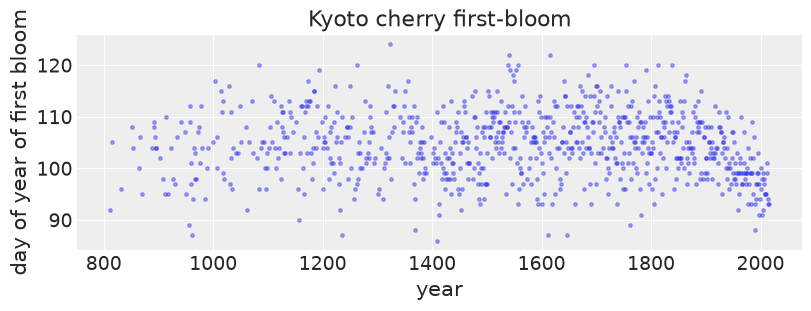

In [4]:
yr = d.year.values.astype(float); doy = d.doy.values.astype(float)
print(f"doy mean {doy.mean():.1f}, sd {doy.std():.1f}")
plt.figure(figsize=(8,3)); plt.scatter(yr, doy, s=6, alpha=.4)
plt.xlabel("year"); plt.ylabel("day of year of first bloom"); plt.title("Kyoto cherry first-bloom"); plt.show()

## Stage 3 — Model specification (B-splines)
$$\text{doy}_i \sim \mathrm{Normal}(\mu_i,\sigma),\quad \mu_i = a + \sum_k w_k B_{k}(\text{year}_i),$$
$$a\sim\mathrm{Normal}(105,10),\ w_k\sim\mathrm{Normal}(0,10),\ \sigma\sim\mathrm{HalfNormal}(10).$$
`B` is a cubic B-spline basis with 17 functions (15 quantile knots). Local basis functions ⇒ the curve
flexes where data demand without a global polynomial's wild tails.

basis matrix: (827, 17)


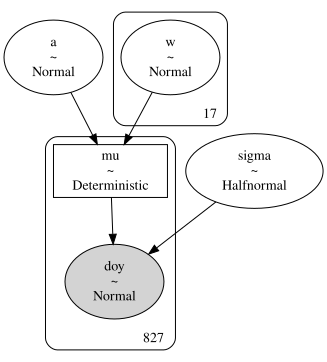

In [5]:
B, knots = bspline_basis(yr, num_knots=15, degree=3)
print("basis matrix:", B.shape)
with pm.Model() as model:
    a = pm.Normal("a", 105, 10)
    w = pm.Normal("w", 0, 10, shape=B.shape[1])
    sigma = pm.HalfNormal("sigma", 10)
    mu = pm.Deterministic("mu", a + pm.math.dot(B, w))
    doy_obs = pm.Normal("doy", mu, sigma, observed=doy)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__)

## Stage 4 — Prior predictive (OUTCOME scale = day of year)

Sampling: [a, doy, sigma, w]


prior-predictive doy: 5-95% = [81, 130] (a day-of-year is ~1-365)


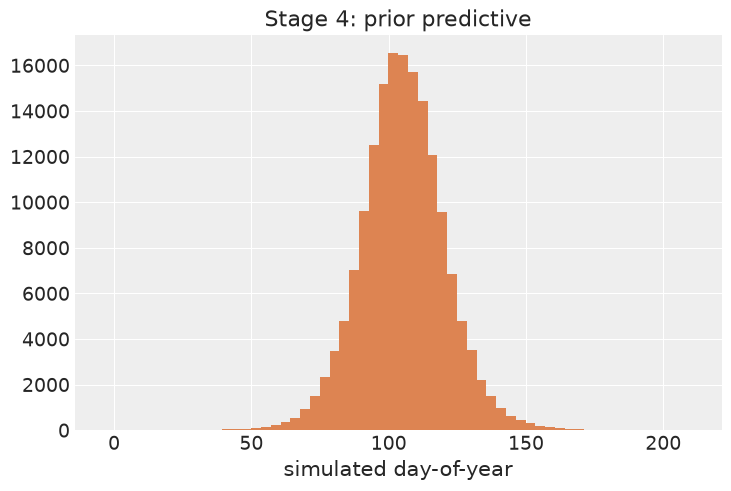

In [6]:
with model:
    prior = pm.sample_prior_predictive(samples=200, random_seed=RANDOM_SEED)
pp = prior.prior_predictive["doy"].values.reshape(-1)
print(f"prior-predictive doy: 5-95% = [{np.percentile(pp,5):.0f}, {np.percentile(pp,95):.0f}] (a day-of-year is ~1-365)")
plt.hist(pp, bins=60, color="#dd8452"); plt.xlabel("simulated day-of-year"); plt.title("Stage 4: prior predictive"); plt.show()

## Stage 5 — Fit

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
    idata = pm.compute_log_likelihood(idata, progressbar=False)
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, w, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 39 seconds.


Sampling: [doy]


wall-clock 40.0s


## Stage 6 — Diagnostics

In [8]:
summ = az.summary(idata, var_names=["a","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","r_hat","ess_bulk","ess_tail"]])
wr = az.summary(idata, var_names=["w"])
print("\nspline weights: max R-hat =", wr["r_hat"].max(), "| min ess_bulk =", int(wr["ess_bulk"].min()))
print("divergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))

          mean     sd  r_hat  ess_bulk  ess_tail
a      103.853  2.404    1.0     670.0     857.0
sigma    5.964  0.145    1.0    3855.0    3119.0

spline weights: max R-hat = 1.0 | min ess_bulk = 836
divergences: 0 | BFMI: [0.931 1.04  1.037 1.029]


## Stage 7 — Interpretation: the smooth trend

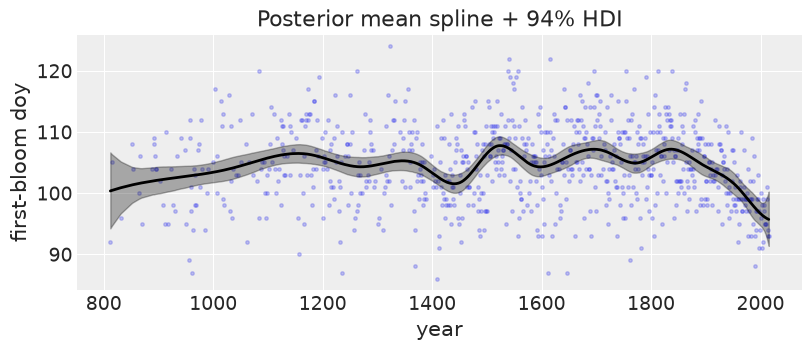

mean bloom-day ~103.3 before 1100 vs ~100.4 after 1900 -> shift of 2.9 days earlier


In [9]:
mu_post = idata.posterior["mu"].stack(s=("chain","draw")).values   # (n_obs, n_draws)
mu_mean = mu_post.mean(1); mu_lo, mu_hi = np.percentile(mu_post, [3,97], axis=1)
order = np.argsort(yr)
plt.figure(figsize=(8,3.4)); plt.scatter(yr, doy, s=6, alpha=.25)
plt.plot(yr[order], mu_mean[order], "k", lw=2)
plt.fill_between(yr[order], mu_lo[order], mu_hi[order], color="k", alpha=.3)
plt.xlabel("year"); plt.ylabel("first-bloom doy"); plt.title("Posterior mean spline + 94% HDI"); plt.show()
early = mu_mean[yr<1100].mean(); late = mu_mean[yr>1900].mean()
print(f"mean bloom-day ~{early:.1f} before 1100 vs ~{late:.1f} after 1900 -> shift of {early-late:.1f} days earlier")

## Stage 8 — Posterior predictive check

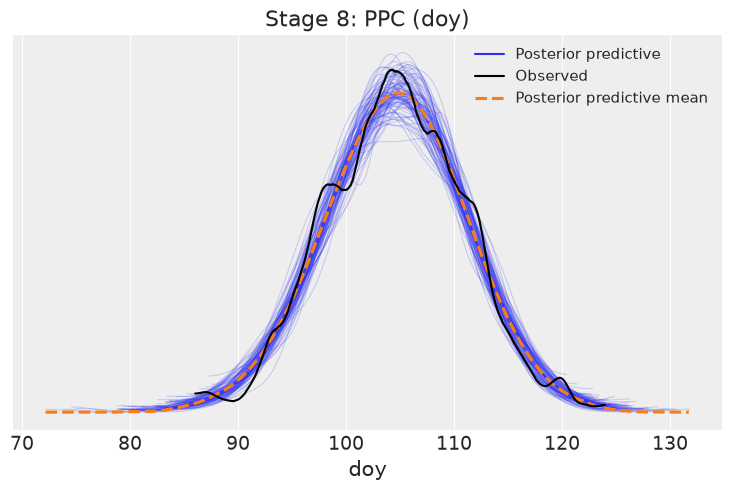

  mean: obs= 104.54  bayes-p=0.50
  sd  : obs=   6.40  bayes-p=0.64
  min : obs=  86.00  bayes-p=0.09
  max : obs= 124.00  bayes-p=0.57


In [10]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC (doy)"); plt.show()
ppc = idata.posterior_predictive["doy"].values.reshape(-1, doy.size)
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(doy):7.2f}  bayes-p={(fn(ppc,axis=1)>=fn(doy)).mean():.2f}")

## Stage 9 — Comparison: spline vs linear trend (PSIS-LOO)

In [11]:
yz = (yr - yr.mean())/yr.std()
with pm.Model() as model_lin:
    a = pm.Normal("a", 105, 10); b = pm.Normal("b", 0, 10); sigma = pm.HalfNormal("sigma", 10)
    pm.Normal("doy", a + b*yz, sigma, observed=doy)
    idata_lin = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                          progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"spline": idata, "linear": idata_lin})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size*idata.posterior.chain.size
print(f"\nmax Pareto k-hat (spline): {az.loo(idata, pointwise=True).pareto_k.values.max():.2f} | threshold {min(1-1/np.log10(S),0.7):.2f}")
print(f"elpd_diff/dse = {cmp['elpd_diff'].iloc[1]/cmp['dse'].iloc[1]:.1f} SE")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


        rank     elpd_loo  elpd_diff       dse        weight
spline     0 -2658.137188   0.000000  0.000000  1.000000e+00
linear     1 -2710.885100  52.747912  9.916637  1.277778e-11



max Pareto k-hat (spline): 0.37 | threshold 0.70
elpd_diff/dse = 5.3 SE


## Stage 10 — Power-scaling prior sensitivity (sigma)

In [12]:
post = az.extract(idata); sig_d = post["sigma"].values
logprior = st.halfnorm.logpdf(sig_d, scale=10)
print("alpha   E[sigma]")
for al in [0.8,1.0,1.25]:
    wgt=np.exp((al-1)*logprior); wgt/=wgt.sum(); print(f" {al:4.2f}   {np.sum(wgt*sig_d):.3f}")

alpha   E[sigma]
 0.80   5.964
 1.00   5.964
 1.25   5.963


## SBC — Simulation-Based Calibration (Tier 4 requirement)
We run SBC on the noise σ of a **reduced 6-knot spline** (keeps each of 100 fits cheap). Draw σ̃ from
the prior, simulate `doy`, fit, record the rank of σ̃ among posterior draws. Ranks should be ~uniform
(Talts et al. 2018; Säilynoja et al. 2022).

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, w, sigma]


Sampling 2 chains for 400 tune and 300 draw iterations (800 + 600 draws total) took 6 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, w, sigma]


Sampling 2 chains for 400 tune and 300 draw iterations (800 + 600 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


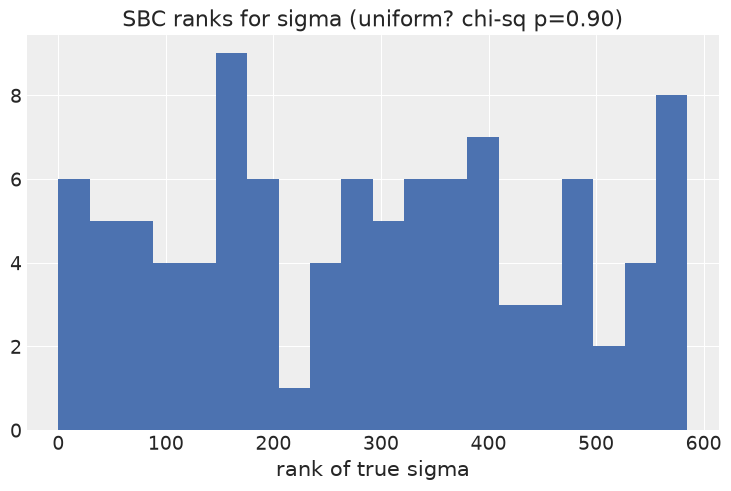

SBC: 100 sims | chi-square uniformity p=0.90 (>0.05 = consistent with uniform)


In [13]:
yr_sbc = np.linspace(1000, 2000, 120)
Bs, _ = bspline_basis(yr_sbc, num_knots=6)
n_sim, ranks = 100, []
for i in range(n_sim):
    a_t = rng.normal(105,10); w_t = rng.normal(0,10,Bs.shape[1]); s_t = abs(rng.normal(0,10))
    y_t = rng.normal(a_t + Bs@w_t, s_t)
    with pm.Model() as ms:
        a = pm.Normal("a",105,10); w = pm.Normal("w",0,10,shape=Bs.shape[1]); sigma = pm.HalfNormal("sigma",10)
        pm.Normal("y", a+pm.math.dot(Bs,w), sigma, observed=y_t)
        ids = pm.sample(300, tune=400, chains=2, target_accept=0.9, random_seed=i, progressbar=False)
    draws = ids.posterior["sigma"].values.ravel()
    ranks.append(int((draws < s_t).sum()))
ranks = np.array(ranks); L = len(draws)
chi = st.chisquare(np.histogram(ranks, bins=10, range=(0,L))[0]).pvalue
plt.hist(ranks, bins=20, color="#4c72b0"); plt.title(f"SBC ranks for sigma (uniform? chi-sq p={chi:.2f})")
plt.xlabel("rank of true sigma"); plt.show()
print(f"SBC: {n_sim} sims | chi-square uniformity p={chi:.2f} (>0.05 = consistent with uniform)")

## (Optional) HSGP — Hilbert-space approximate GP
The scalable GP alternative (§7.7): a low-rank basis approximation that captures the same smooth trend
at far less than O(n³). Shown here as the bridge to genuine GP models.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [eta, ell, f_hsgp_coeffs, a, sigma]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 12 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


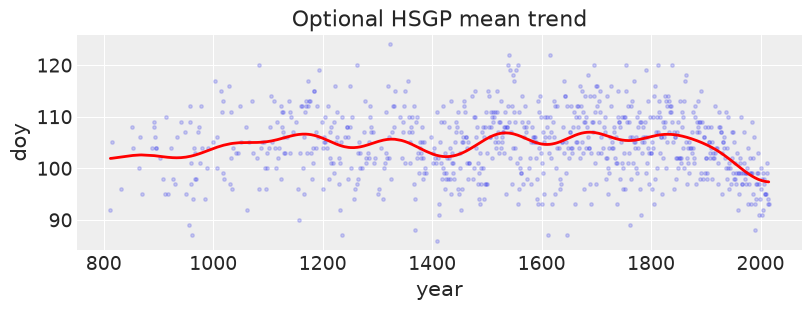

HSGP divergences: 2


In [14]:
try:
    with pm.Model() as model_hsgp:
        eta = pm.Exponential("eta", 1.0); ell = pm.Gamma("ell", 4, 1.0)
        cov = eta**2 * pm.gp.cov.Matern52(1, ls=ell)
        gp = pm.gp.HSGP(m=[30], c=1.5, cov_func=cov)
        f = gp.prior("f", X=yz[:,None])
        a = pm.Normal("a",105,10); sigma = pm.HalfNormal("sigma",10)
        pm.Normal("doy", a+f, sigma, observed=doy)
        idata_hsgp = pm.sample(800, tune=800, chains=2, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
    fpost = (idata_hsgp.posterior["a"].values.reshape(-1,1) + idata_hsgp.posterior["f"].values.reshape(-1, doy.size))
    fm = fpost.mean(0); od=np.argsort(yr)
    plt.figure(figsize=(8,3)); plt.scatter(yr,doy,s=6,alpha=.2); plt.plot(yr[od],fm[od],"r",lw=2)
    plt.title("Optional HSGP mean trend"); plt.xlabel("year"); plt.ylabel("doy"); plt.show()
    print("HSGP divergences:", int(idata_hsgp.sample_stats.diverging.values.sum()))
except Exception as e:
    print("HSGP cell skipped:", type(e).__name__, e)

## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** join the bloom series to the **temperature** reconstruction (`temp`) to turn
a descriptive trend into a mechanistic temperature→bloom model; or replace the B-spline with the HSGP
above for principled extrapolation uncertainty.

**Decision (Stage 12) — headline:** *Kyoto's first cherry blossom now arrives several days earlier than
it did a millennium ago; the B-spline recovers a smooth, well-mixed trend (R̂≈1.0, 0 divergences) at a
fraction of an exact GP's cost, and SBC confirms the noise model is calibrated.*

In [15]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P18_idata.nc"); print("saved report/P18_idata.nc")

saved report/P18_idata.nc


## Exercises
1. Vary `num_knots` (5, 15, 30). How does the curve's wiggliness and LOO change? What controls overfitting?
2. Fit `doy ~ temp` directly and quantify days-per-°C; compare its LOO to the time-only spline.
3. Use the HSGP model to predict bloom day for years 2025–2050 with calibrated uncertainty, and discuss
   why extrapolating a B-spline is dangerous where the GP is more honest.